# 01 — Data Preparation and Initial EDA
**AAI-500 Final Team Project — Predicting Credit Card Default**

This notebook loads the UCI *Default of Credit Card Clients* dataset, checks data quality,
applies the cleaning steps in `src/cleaning.py`, and saves a cleaned copy to `data/processed/`.
It ends with a first look at the target and the key predictors. Deeper EDA and statistical
tests continue in `02_eda_statistical_tests.ipynb`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Make the project's src/ package importable from the notebooks/ folder
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_raw, PROCESSED_DIR
from src import cleaning

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load the raw data
The loader downloads the file from UCI on first run and caches it in `data/raw/`.

In [2]:
raw = load_raw()
print(raw.shape)
raw.head()

(30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 2. Data quality checks

In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_AMT3        

In [4]:
print("Missing values:", raw.isna().sum().sum())
print("Duplicate rows (ignoring ID):", raw.drop(columns="ID").duplicated().sum())

Missing values: 0
Duplicate rows (ignoring ID): 35


### Category codes vs. the documentation
The UCI documentation lists EDUCATION as 1–4 and MARRIAGE as 1–3, and repayment status
(`PAY_*`) as -1 = paid duly, 1–9 = months of delay. The data contains codes outside those lists.

In [5]:
for col in ["EDUCATION", "MARRIAGE", "PAY_0"]:
    print(col)
    print(raw[col].value_counts().sort_index().to_string(), "\n")

EDUCATION
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51 

MARRIAGE
MARRIAGE
0       54
1    13659
2    15964
3      323 

PAY_0
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19 



**Decisions** (documented for the report's Data Cleaning section):

| Issue | Rows affected | Action | Why |
|---|---|---|---|
| `ID` column | all | Drop | Row identifier, no predictive meaning |
| Exact duplicates (ignoring ID) | 35 | Drop | Would double-count the same client |
| `EDUCATION` = 0, 5, 6 | 345 | Map to 4 ("Other") | Undocumented and rare |
| `MARRIAGE` = 0 | 54 | Map to 3 ("Other") | Undocumented and rare |
| `PAY_*` = -2, 0 | many | Keep as-is | Common in the literature to read -2 as "no balance/no use" and 0 as "revolving credit, minimum paid". These are real states, not errors |
| `PAY_0` naming | — | Rename to `PAY_1` | Aligns with `BILL_AMT1` / `PAY_AMT1` |
| Target name | — | Rename to `DEFAULT` | Shorter, easier to reference |

## 3. Apply cleaning and save

In [6]:
df = cleaning.clean(raw)
print(df.shape)
for col in ["EDUCATION", "MARRIAGE"]:
    print(col, df[col].value_counts().sort_index().to_dict())

Dropped 35 duplicate rows
(29965, 24)
EDUCATION {1: 10563, 2: 14019, 3: 4915, 4: 468}
MARRIAGE {1: 13643, 2: 15945, 3: 377}


In [7]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
out_path = PROCESSED_DIR / "credit_default_clean.csv"
df.to_csv(out_path, index=False)
print("Saved", out_path.relative_to(PROJECT_ROOT))

Saved data/processed/credit_default_clean.csv


## 4. First look: the target

Default rate: 22.1%  (6,630 of 29,965 clients)


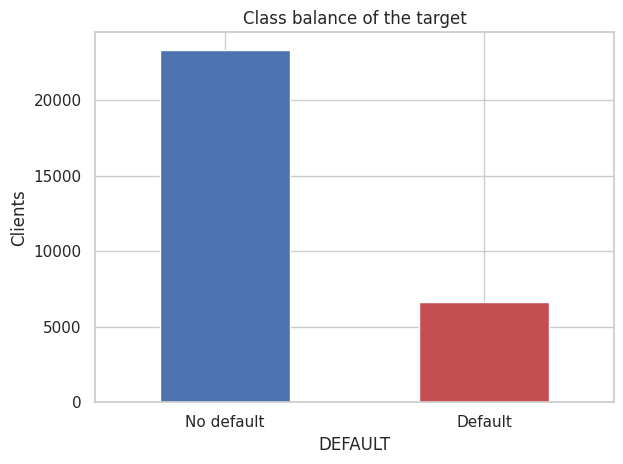

In [8]:
rate = df[cleaning.TARGET].mean()
print(f"Default rate: {rate:.1%}  ({df[cleaning.TARGET].sum():,} of {len(df):,} clients)")

ax = df[cleaning.TARGET].map({0: "No default", 1: "Default"}).value_counts().plot.bar(rot=0, color=["#4C72B0", "#C44E52"])
ax.set_title("Class balance of the target")
ax.set_ylabel("Clients")
plt.tight_layout()
plt.savefig(FIG_DIR / "target_balance.png", dpi=150)
plt.show()

About 22% of clients default. The classes are imbalanced, so plain accuracy is misleading
(always predicting "no default" scores ~78%). Model evaluation will use ROC-AUC, precision,
recall and F1.

## 5. First look: default rate by key predictors

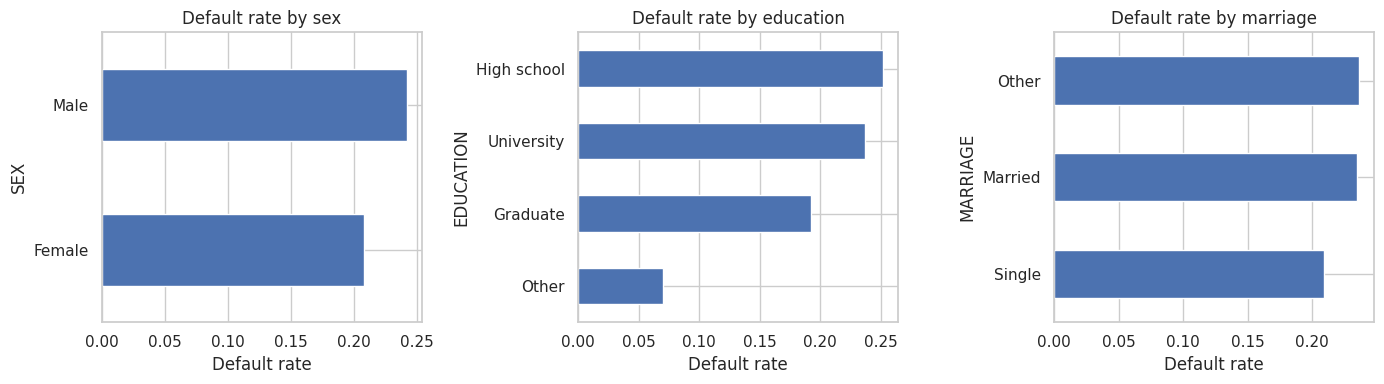

In [9]:
labeled = cleaning.add_labels(df)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["SEX", "EDUCATION", "MARRIAGE"]):
    labeled.groupby(col)[cleaning.TARGET].mean().sort_values().plot.barh(ax=ax, color="#4C72B0")
    ax.set_title(f"Default rate by {col.lower()}")
    ax.set_xlabel("Default rate")
plt.tight_layout()
plt.savefig(FIG_DIR / "default_rate_by_demographics.png", dpi=150)
plt.show()

In [10]:
# Most recent repayment status is expected to be the strongest single signal
pay1 = df.groupby("PAY_1")[cleaning.TARGET].agg(["mean", "size"]).rename(columns={"mean": "default_rate", "size": "clients"})
pay1

,default_rate,clients
PAY_1,,
-2,0.132364,2750
-1,0.167899,5682
0,0.128113,14737
1,0.340333,3667
2,0.691298,2666
3,0.757764,322
4,0.684211,76
5,0.500000,26
6,0.545455,11


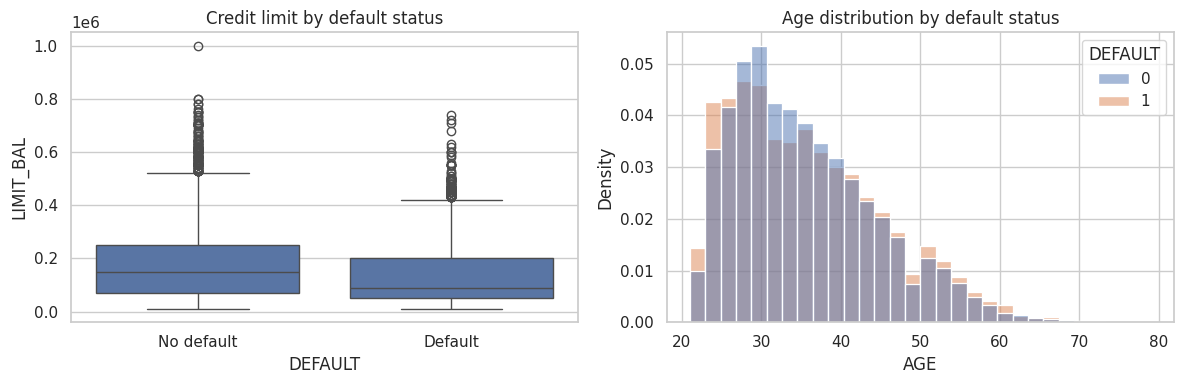

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=labeled, x=cleaning.TARGET, y="LIMIT_BAL", ax=axes[0])
axes[0].set_title("Credit limit by default status")
axes[0].set_xticks([0, 1], ["No default", "Default"])
sns.histplot(data=labeled, x="AGE", hue=cleaning.TARGET, stat="density", common_norm=False, bins=30, ax=axes[1])
axes[1].set_title("Age distribution by default status")
plt.tight_layout()
plt.savefig(FIG_DIR / "limit_age_by_default.png", dpi=150)
plt.show()

## Next steps
- **02_eda_statistical_tests** — chi-square tests for the categorical variables vs. default,
  t-tests / Mann-Whitney for `LIMIT_BAL`, `AGE`, bill and payment amounts; correlation heatmap and
  VIF for the six `BILL_AMT` columns.
- **03_modeling** — train/test split (stratified), baseline logistic regression with odds ratios,
  comparison model(s), threshold tuning.
- **04_evaluation** — ROC-AUC, confusion matrix, precision/recall at the chosen threshold,
  business interpretation.